**CMSE201 Semester Project - Submitted 06/26/2026**
**Ava E. Fronek**

*Research Question: How does Shielding Constant change throughout electrons in an atom?*

i.e. How attracted are electrons to the nucleus as they get further out? How does the shielding effect look for each orbital in the elements?

**Research Background**

Inner electrons are closer and more strongly pulled to the nucleus (opposite charges attract)

Outer electrons experience much less pull to the nucleus, not just because of distance, but because inner electrons, which are strongly held in, repel outer electrons due to like charges.


Shielding effect:
Inner electrons repel outer electrons, increasing their energy and making them less attracted to the nucleus! It is coined "shielding" because inner electrons essentially block outer electrons from being as attracted as they could be purely based on their position in an atom. This concept is an important factor in chemical bonding, as electrons that are partially blocked in their attraction to the nucleus are loosely bound to the atom, and more readily available to provide electrons in chemical bonding!

Orbital Geometry:
Slater's rules dictates that electrons in orbitals with a higher l (angular momentum) quantum numberwill experience more shielding; in the order of s<p<d<f. The strong shielding effects of an f orbital is seen in many of the atoms with 58 or more protons. As an example, use the user input and type in 92U to see the barchart and where 5f shielding constant doesn't follow the typical pattern.

**Context, Assumptions, and Potential Bias**

Here is the link to the data set I am using: https://www.nist.gov/pml/atomic-reference-data-electronic-structure-calculations

The data gives values for different element's energies (total, kinetic, coulombic, etc.). It also gives energy eigenvalues for each of an element's atomic orbitals, which is the part of the data being modeled.

**Context**: Uses a Density Functional Theory (DFT) approach with multiple approximation methods. All the data given in the table is in Hartree units. In these units, the speed of light is given by the inverse of the fine structure constant. Besides the source of data being very well organized, it also gives all of the mathematical background used in the calculations. The data also gives neutral and cationic state data. Datafiles are .txt files and are named analagous to '02He'. The dataset organizes the orbital names (e.g. 3p, 3d, 4s, 4p) in order of n (principle quantum) number and then l (angular momentum) quantum number, and NOT the filling order of the atom. 

**Assumptions**: The assumption of the data set is that each atom is in its ground state electronic configuration. This is a straightforward assumption to make, as the data is obtained by calculation and not experimentation. The fine structure constant is used to obtain the numerical value of the speed of light, c = 137.0359895. The data set includes the ground state electronic configurations for each atom, and the eigenvalues are drawn from operators which include shielding effects. Atoms are extremely complex systems with many interactions and coupling schemes. The eigenvalues taken from NIST already include approximations like, making Zeff and the shielding constant quite accurate. When using energy eigenvalues to calculate Zeff (and thus shielding constant), I used the Bohr Approximation. The energy already holds the weight of shielding effects, but it is important ot note that the formula was used.

**Potential Biases (Approximation Methods)**: The "bias" in the data set is that it is limited to elements up to Uranium. Not much of a bias, but important when iterating the data. The data is also calculated using approximation methods. They are as follows:
- Local-density approximation (LDA),
- Local spin-density approximation (LSD),
- Relativistic local-density approximation (RLDA)
- Scalar-relativistic local-density approximation (ScRLDA).

First, import 3 necessary packages. If you are using this code, make sure to download the dataset from the NIST link before beginning.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Begin by initializing an array of atomic numbers along with a list that will be used to call on datasets in the data folders. The dataset names are analagous to each other and follow the same format. This was typed by brute force.

In [3]:
Z_list=np.arange(1,93,1) #Proton numbers for later

#Manually make a list of strings to call on values
element_list=['01H','02He','03Li','04Be', '05B', '06C', '07N', '08O', '09F', '10Ne', '11Na', '12Mg', '13Al', '14Si', '15P', '16S', '17Cl', '18Ar', '19K', '20Ca', '21Sc', '22Ti', '23V', '24Cr', '25Mn', '26Fe', '27Co', '28Ni', '29Cu', '30Zn', '31Ga', '32Ge', '33As', '34Se', '35Br', '36Kr', '37Rb', '38Sr', '39Y', '40Zr', '41Nb', '42Mo', '43Tc', '44Ru', '45Rh', '46Pd', '47Ag', '48Cd', '49In', '50Sn', '51Sb', '52Te', '53I', '54Xe', '55Cs', '56Ba', '57La', '58Ce', '59Pr', '60Nd', '61Pm', '62Sm', '63Eu', '64Gd', '65Tb', '66Dy', '67Ho', '68Er', '69Tm', '70Yb', '71Lu', '72Hf', '73Ta', '74W', '75Re', '76Os', '77Ir', '78Pt', '79Au', '80Hg', '81Tl', '82Pb', '83Bi', '84Po', '85At', '86Rn', '87Fr', '88Ra', '89Ac', '90Th', '91Pa', '92U']


Next, test the data for Phosphorus. I wanted to print the table of values and attempt to print some values. I had to add some extra arguments and functions found online to make this work, such as .to_csv and including 'f' before the csv name. This is key in constructing dynamic file paths, increasing the usability and the code. When the dictionary is made, there must be a whitespace delimiter and some rows to skip to clean up the data and call on separated values.

In [10]:
#I'm not using the energy values for each atom, only the energy eigenvalues for each orbital. 
LDA15P=pd.read_csv(f'dftdata/LDA/neutrals/15P')
LDA15P.to_csv('dftdata/LDA/neutrals/15P', 
                  index = 0)
print(LDA15P.head())
LDA15P.iloc[5,:]
print(LDA15P.iloc[4,0]) #prints orbital AND value (not ideal): They start at row 4 because pandas reads total energy as a column header.


    Etot  =     -339.946219
0   Ekin  =      339.173459
1   Ecoul =      153.065007
2   Eenuc =     -810.400100
3   Exc   =      -21.784585
4      1s        -76.061897
 1s        -76.061897


The code above shows that there exists whitespace between orbital and eigenvalue entries. This is seen by the fact that indexing the first column prints two separate values that are needed. I need to add a delimiter for the whitespace. I also want to clean up the data by removing total energy values. This means I need to skip 5 rows. 5 being because the E_tot value is not actually indexed but is in the way. Below shows using skiprows and sep arguments to do these two things. 

Then, a dictionary was created, attaching keys from element_list to respective datasets in the folder. This was done by using an f-string and then indexing in a path using curly brackets and named the keys respectively. I renamed the columns as well to make calling columns simpler. Test the data and retreive values to ensure datasets work. Trying with Oxygen for different index sizes.

In [8]:
Zeff_list=[] #Effective proton number. For now, this is used calculating the OUTERMOST shell's Zeff.

#Assign all the data sets for every element
mydictionary={} #This will hold the name of the dataset to its dataset
#This loading will separate by spaces, split the columns into orbital and eigenvalue, and remove the total energies that are irrelevant to this project.
#So I tweaked the sep argument to be whitespace and skipped the rows with values like KE_tot and E_tot.
for element in element_list:
    mydictionary["{0}".format(element)]=pd.read_csv(f'dftdata/LDA/neutrals/{element}',sep='\s+',names=['Orbital', 'Eigenvalue'],skiprows=5 )
#I printed the whole dictionary to make sure this works

print(mydictionary['08O']) #test it!
print(mydictionary['08O'].iloc[1,0]) #test it! THIS IS GOOD 
print(mydictionary['08O'].iloc[1,1]) #test it! YYESSSSSSS!!!

  Orbital  Eigenvalue
0      1s  -18.758245
1      2s   -0.871362
2      2p   -0.338381
2s
-0.871362


<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
C:\Users\frone\AppData\Local\Temp\ipykernel_27656\2563669006.py:8: SyntaxWarning: invalid escape sequence '\s'
  mydictionary["{0}".format(element)]=pd.read_csv(f'dftdata/LDA/neutrals/{element}',sep='\s+',names=['Orbital', 'Eigenvalue'],skiprows=5 )


As you can tell by my excitement, the dictionary worked! There are two syntax warnings, but they to not impede on any of the code's functionality. Now that I have the dictionary of elements, and each element's orbitals and their eigenvalues separated, the next step is to do plot the energy throughout the orbitals and see what I can find. As a test, I chose to use Radium (called by 88Ra). I chose to use a barchart, which requires me to take the absolute value of the energy values. Negative energy implies the *attraction* to the nucleus, so the barchart's y-axis is denoted as magnitude. I found that the energy in the first electron region was insanely high and the other energies were difficult to read. For this reason, I used a logscale on my y-axis. The magnitude of energy is NOT used in Zeff or shielding constant calculations for accuracy reasons.

   Orbital   Eigenvalue
0       1s -3362.736563
1       2s  -577.101208
2       2p  -557.513214
3       3s  -142.632426
4       3p  -133.123250
5       3d  -115.306476
6       4s   -34.525628
7       4p   -30.221208
8       4d   -22.208125
9       4f   -11.181066
10      5s    -7.139137
11      5p    -5.547203
12      5d    -2.819853
13      6s    -1.051350
14      6p    -0.634674
15      7s    -0.113732


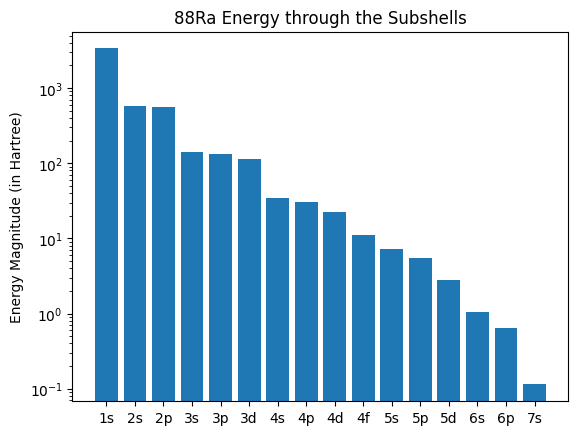

In [11]:
print(mydictionary['88Ra'])
import matplotlib.pyplot as plt

orbital = mydictionary['88Ra'].iloc[:,0] #Make plotting variables, this will be used in future graphings too.
energy = np.abs(mydictionary['88Ra'].iloc[:,1]) #Take the absolute value so the bar chart is readable

plt.bar(orbital, energy)

plt.ylabel('Energy Magnitude (in Hartree)')
plt.title('88Ra Energy through the Subshells')
plt.yscale('log') #Add a logscale

plt.show() #This is a graph for just the energy at each subshell

Now that the energy is plotted, I will solve for the nuclear effective charge throughout the subshells. This is a middle-ground step that can be excluded from results, but it paints a different picture. This will mainly be used as a stepping stone to plot the shielding constant and get something telling of physical interactions. To find the nuclear effective charge, Zeff, I used the Bohr Model approximation. Because the approximation methods account for shielding, this approximation is acceptable for the qualitative research question, as the energy eigenvalues are derived from an operator that accounts for the effects. Rearranging the Bohr model's energy equation, we append Zeff values to a list that is then plotted over the same orbital region. A logscale is not needed here.

Bohr Model Approximation: $E = \frac{-13.6 × Zeff^2}{n^2}\rightarrow Zeff=\sqrt{\frac{E*n^2}{-13.6}}$ 

This must be done in units of Hartree to correlate with the dataset properly. Also making sure that the energy value used is NOT as a magnitude and stays negative, this way Zeff can be really solved.

<class 'str'>
-3362.736563
16
[np.float64(82.02556300602494), np.float64(67.96084722944181), np.float64(66.79752563697075), np.float64(50.67960090766159), np.float64(48.96108208518482), np.float64(45.567048744876395), np.float64(33.24555456365115), np.float64(31.10417582875139), np.float64(26.663596892855733), np.float64(18.91927081439016), np.float64(18.897121673673805), np.float64(16.65750034392077), np.float64(11.876433348711938), np.float64(8.70217288027739), np.float64(6.761287467156637), np.float64(3.339198027485747)]
True


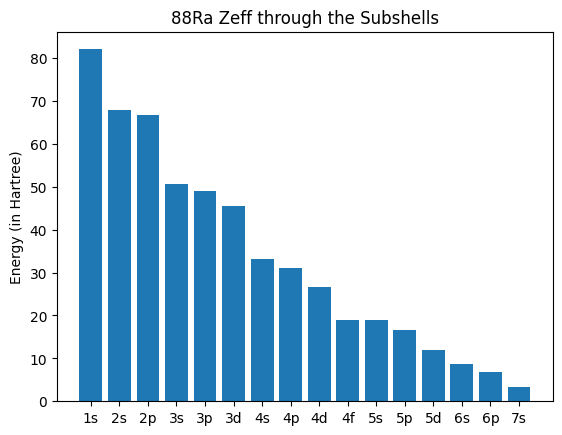

In [22]:
#Calculate Zeff using the orbital eigenvalues as an approximate for binding energy
#Using the Bohr Model approximation

Zefflist=[] #Analagous to proton number -1 to call it
#E=-13.6*Zeff^2/n^2 -> Zeff=sqrt(E*n^2/(-13.6))
print(type(mydictionary['88Ra'].iloc[0,0][0])) #retrieve n, shell number, returns as a string, the number must be turned into a float.
print(mydictionary['88Ra'].iloc[0,1]) #ensure energy number
print(len(mydictionary['88Ra'].iloc[:,1]))
#Convert eV to hartree
R=-13.6/27.211

for orbital in range(0,len(mydictionary['88Ra'].iloc[:,1])):
    energy_for_orbital=mydictionary['88Ra'].iloc[orbital,1]

    shell_number=float((mydictionary['88Ra'].iloc[orbital,0][0])) #This takes the first string value which is a number, turns it into a float, and 
                                                                  #uses that as the energy level for calculation. This was the simplest way to 
                                                                  #retrieve each n for calculation.

    Zefflist.append(np.sqrt((energy_for_orbital)*(shell_number**2)/(R))) #Here is the Bohr model formula

print(Zefflist)

#Sanity check
if len(Zefflist)==len(mydictionary['88Ra'].iloc[:,0]):
    print("True")
else:
    print("False")



orbital = mydictionary['88Ra'].iloc[:,0]

plt.bar(orbital, np.abs(Zefflist))

plt.ylabel('Energy (in Hartree)')
plt.title('88Ra Zeff through the Subshells')


plt.show() #This is a graph for just the energy at each subshell

For the shielding value plot, we append shielding constants to a list which is calculated by taking the nuclear charge subtracted by the effective nuclear charge. Those values are also plotted over the same orbitals.

$Z=Z_{eff}-\sigma \rightarrow \sigma=Z_{eff}-Z$

[np.float64(5.974436993975061), np.float64(20.03915277055819), np.float64(21.202474363029253), np.float64(37.32039909233841), np.float64(39.03891791481518), np.float64(42.432951255123605), np.float64(54.75444543634885), np.float64(56.895824171248606), np.float64(61.336403107144264), np.float64(69.08072918560984), np.float64(69.10287832632619), np.float64(71.34249965607923), np.float64(76.12356665128806), np.float64(79.29782711972261), np.float64(81.23871253284337), np.float64(84.66080197251425)]


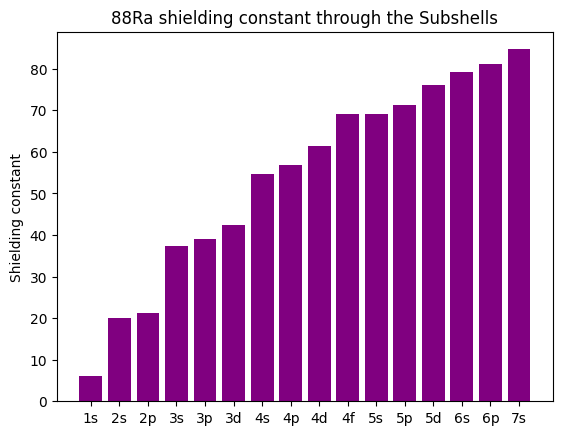

In [23]:
#Now shielding constant

shieldinglist=[]

for i in range(0,len(mydictionary['88Ra'].iloc[:,1])):
    shieldinglist.append(Z_list[87]-Zefflist[i]) #Index 87 to get the proton (Z) number 88 for Radium from Z_list
print(shieldinglist)

orbital = mydictionary['88Ra'].iloc[:,0]
plt.bar(orbital, shieldinglist, color='purple')

plt.ylabel('Shielding constant')
plt.title('88Ra shielding constant through the Subshells')

plt.show() #This is a graph for just the energy at each subshell

This looks great! I really want to make this code versatile to the entire dataset, though. I've played around with user inputs in jupyternotebook before so I decided to give that a go. Below shows defining myelement, a desired element in the periodic table, and allowing the user to input the element which is analagous to the data file names in the folders. It is noted not to use strings, and to just type the element in the form analagous to 02He.


**USER INPUT BELOW: pick an element! (up to 92U)**

In [33]:
#Once I have gotten all 3 graphs for 88Ra, I am going back in and doing a user input that can run the graphs for ANY element instead of picking just 1

myelement = input('Enter element code analagous to the elements in element_list *excluding* the strings! Please type element analagous to 02He or 92U:')
print(myelement)
#Just go back and replace '88Ra' with myelement

Enter element code analagous to the elements in element_list *excluding* the strings! Please type element analagous to 02He or 92U: 82Pb


82Pb


The code below is the same format as Radium's plots, just replacing 88Ra with stringed myelement. I had to string the element as I got errors about indexing using my variable, but including strings in the user input also caused issues. Once I included str(), the code works after the user input is provided! I also wanted some cool colors, so I found a matplotlib color pack where I could choose some aesthetic, but still readable colors.

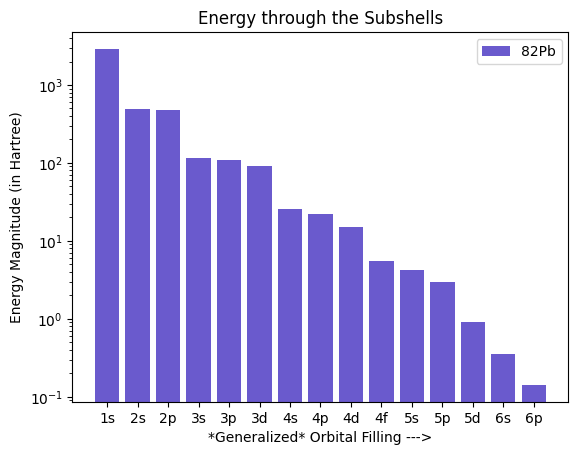

[np.float64(76.1872862241227), np.float64(62.548606954641095), np.float64(61.38848188486128), np.float64(45.80754940986642), np.float64(44.08960028562574), np.float64(40.677850687982804), np.float64(28.713060414874537), np.float64(26.532671025914667), np.float64(21.93525332014252), np.float64(13.380336241796371), np.float64(14.506030260203046), np.float64(12.13022390704007), np.float64(6.7184742998153535), np.float64(5.072264232569119), np.float64(3.196241822046636)]
True


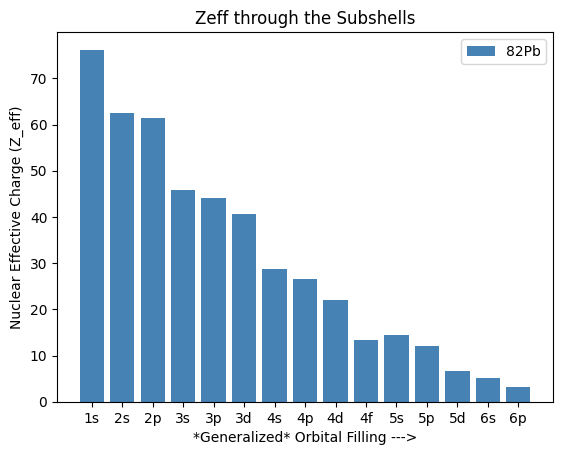

[np.float64(5.812713775877299), np.float64(19.451393045358905), np.float64(20.611518115138722), np.float64(36.19245059013358), np.float64(37.91039971437426), np.float64(41.322149312017196), np.float64(53.28693958512547), np.float64(55.46732897408533), np.float64(60.06474667985748), np.float64(68.61966375820363), np.float64(67.49396973979695), np.float64(69.86977609295992), np.float64(75.28152570018464), np.float64(76.92773576743087), np.float64(78.80375817795337)]


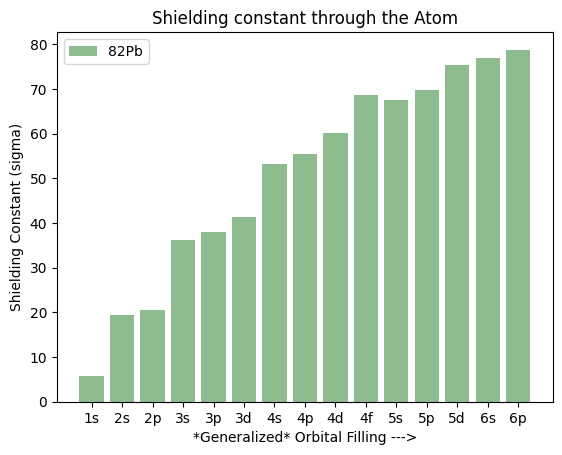

In [34]:
import ast
import matplotlib.colors as mcolors

#Energy Barchart
orbital = mydictionary[str(myelement)].iloc[:,0]  #Now, call using myelement and not 88Ra as test
energy = np.abs(mydictionary[str(myelement)].iloc[:,1])

plt.bar(orbital, energy, color='slateblue',label=str(myelement)) #Use my fancy new colors

#Using absolute value for the bar chart
plt.ylabel('Energy Magnitude (in Hartree)')
plt.xlabel('*Generalized* Orbital Filling --->')
plt.title('Energy through the Subshells')
plt.legend() #Need to signify element in legend because ana error pops up thinking I'm trying to call a dictionary?? anyways...
plt.yscale('log')

plt.show() #This is a graph for just the energy at each subshell



#Zeff Barchart
Zefflist=[]

R=-13.6/27.211

for orbital in range(0,len(mydictionary[str(myelement)].iloc[:,1])):
    energy_for_orbital=mydictionary[str(myelement)].iloc[orbital,1]

    shell_number=float((mydictionary[str(myelement)].iloc[orbital,0][0]))

    Zefflist.append(np.sqrt((energy_for_orbital)*(shell_number**2)/(R)))

print(Zefflist)

if len(Zefflist)==len(mydictionary[str(myelement)].iloc[:,0]):
    print("True")
else:
    print("False")
orbital = mydictionary[str(myelement)].iloc[:,0]

plt.bar(orbital, np.abs(Zefflist), color='steelblue', label=str(myelement))

plt.ylabel('Nuclear Effective Charge (Z_eff)')
plt.xlabel('*Generalized* Orbital Filling --->')
plt.title('Zeff through the Subshells')
plt.legend() #Same error fix here


plt.show() #This is a graph for just the energy at each subshell


#Shielding Barchart
shieldinglist=[]

for i in range(0,len(mydictionary[str(myelement)].iloc[:,1])):
    shieldinglist.append(Z_list[element_list.index(str(myelement))]-Zefflist[i]) #This way of indexing in Z_list will obtain the proton (Z) number
                                                                                 #for the designated atom by finding its index value.
print(shieldinglist)
orbital = mydictionary[str(myelement)].iloc[:,0]
plt.bar(orbital, shieldinglist, color='darkseagreen', label=str(myelement))

plt.ylabel('Shielding Constant (sigma)')
plt.xlabel('*Generalized* Orbital Filling --->')
plt.title('Shielding constant through the Atom')
plt.legend() #And same bug fix here

plt.show() #This is a graph for just the energy at each subshell

Lastly, I want to make a phase portrait. I will model the shielding constant against the energy to see its relationship. I hypothesize some sort of quadratic or rational fit due to the proportionality between E and Z^2. For readability, I wanted to ensure I didn't take the absolute value of the energy, mainly because I wanted the plot to resemble some notion of distance from the nucleus (to show distance is *not* sufficient to describe energy of electrons in an atom like the Bohr model had suggested). A logscale didn't work for this data. Maybe it would have if I had plotted energy versus shielding, but I think that model is harder to pick up its message. Instead, I started plotting once 24 electrons (12 orbitals) have been filled. I utilized both pandas and numpy indexing to achieve this. This makes the phase diagram zoom in on the area that electrons become loosely bound in the atom, seen by the triangle-like loop on the second plot.

**If you are choosing an element, you might need to adjust the star-commented line to zoom in on the second (zoomed in) phase portrait where the f-orbital strays from the typical shielding pattern. What is currently there works for Uranium and Protactinium, but not for something like 58Ce. Also note that some elements that have f-orbitals may not show the misfollowed trend. For example, Radium and Lanthanum do not, but Lead and Protactinium do. These all happen for various reasons, whether that be due to Hund's rules filling or some kind of shielding rearrangement. More analysis would have to be done to understand elements with 57 protons or more.**

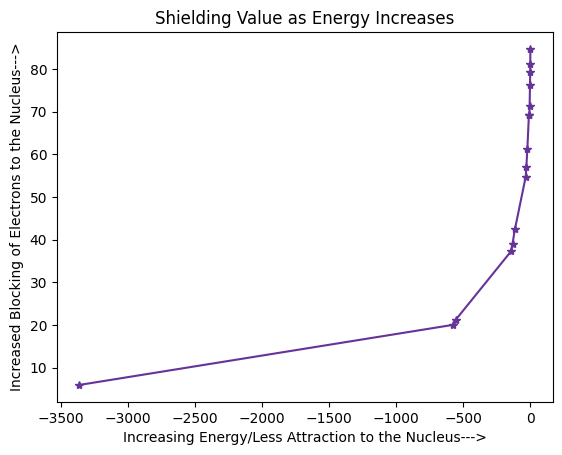

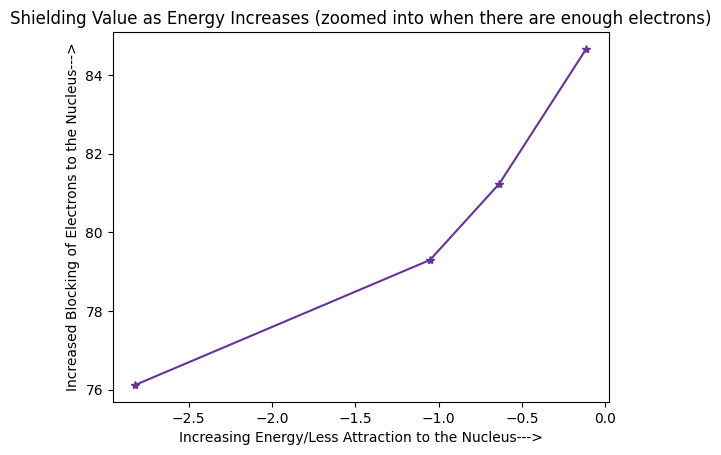

In [29]:
nonabsenergy=mydictionary[str(myelement)].iloc[:,1]
plt.plot(nonabsenergy,shieldinglist, color='rebeccapurple', marker='*')
plt.xlabel('Increasing Energy/Less Attraction to the Nucleus--->')
plt.ylabel('Increased Blocking of Electrons to the Nucleus--->')
plt.title('Shielding Value as Energy Increases')


plt.show()

nonabsenergy=mydictionary[str(myelement)].iloc[12:,1]
plt.plot(nonabsenergy,shieldinglist[12:], color='rebeccapurple', marker='*')
plt.xlabel('Increasing Energy/Less Attraction to the Nucleus--->')
plt.ylabel('Increased Blocking of Electrons to the Nucleus--->')
plt.title('Shielding Value as Energy Increases (zoomed into when there are enough electrons)')


plt.show()

**Results:** Run this code below to return only the graphs for a designated atom:

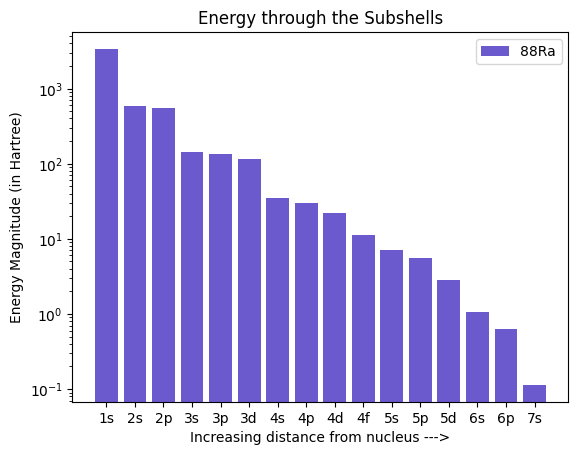

True


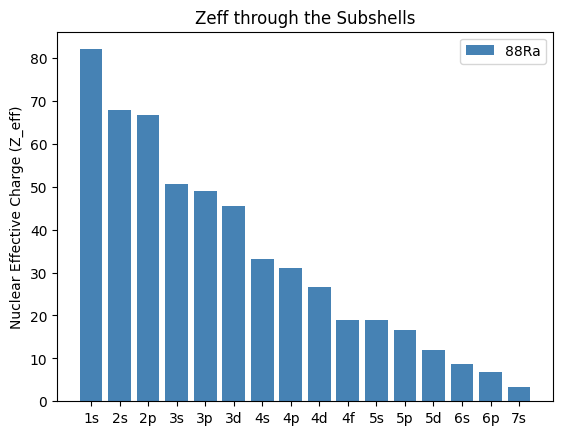

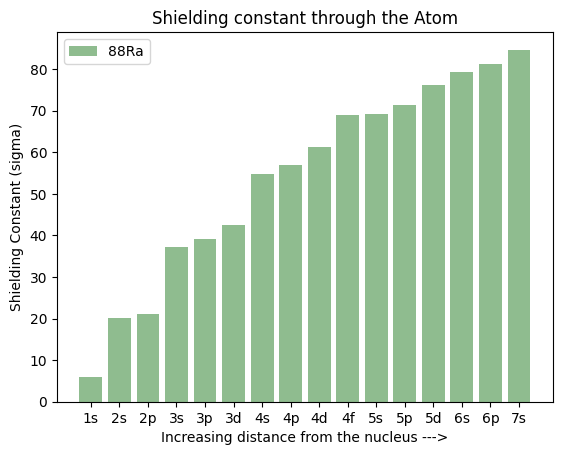

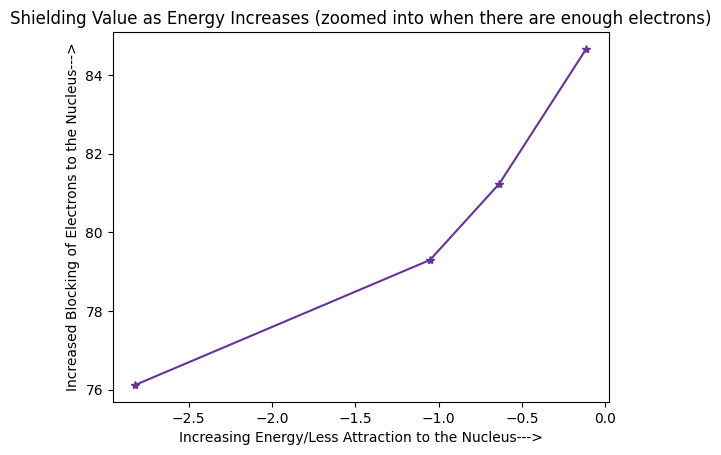

In [28]:

plt.bar(orbital, energy, color='slateblue',label=str(myelement))

#Using absolute value for the bar chart
plt.ylabel('Energy Magnitude (in Hartree)')
plt.xlabel('Increasing distance from nucleus --->')
plt.title('Energy through the Subshells')
plt.legend()
plt.yscale('log')
plt.show()
#Zeff Barchart
Zefflist=[]

R=-13.6/27.211

for orbital in range(0,len(mydictionary[str(myelement)].iloc[:,1])):
    energy_for_orbital=mydictionary[str(myelement)].iloc[orbital,1]

    shell_number=float((mydictionary[str(myelement)].iloc[orbital,0][0]))

    Zefflist.append(np.sqrt((energy_for_orbital)*(shell_number**2)/(R)))


if len(Zefflist)==len(mydictionary[str(myelement)].iloc[:,0]):
    print("True")
else:
    print("False")
orbital = mydictionary[str(myelement)].iloc[:,0]

plt.bar(orbital, np.abs(Zefflist), color='steelblue', label=str(myelement))

plt.ylabel('Nuclear Effective Charge (Z_eff)')
plt.title('Zeff through the Subshells')
plt.legend() #Same error fix here
plt.show()

#Shielding Barchart
shieldinglist=[]
for i in range(0,len(mydictionary[str(myelement)].iloc[:,1])):
    shieldinglist.append(Z_list[element_list.index(str(myelement))]-Zefflist[i]) 
orbital = mydictionary[str(myelement)].iloc[:,0]
plt.bar(orbital, shieldinglist, color='darkseagreen', label=str(myelement))
plt.ylabel('Shielding Constant (sigma)')
plt.xlabel('Increasing distance from the nucleus --->')
plt.title('Shielding constant through the Atom')
plt.legend() #And same bug fix here
plt.show()
nonabsenergy=mydictionary[str(myelement)].iloc[12:,1]
plt.plot(nonabsenergy,shieldinglist[12:], color='rebeccapurple', marker='*')
plt.xlabel('Increasing Energy/Less Attraction to the Nucleus--->')
plt.ylabel('Increased Blocking of Electrons to the Nucleus--->')
plt.title('Shielding Value as Energy Increases (zoomed into when there are enough electrons)')
plt.show()

**Discussion:**

Obstacles I ran into: 

- Unpacking folders of folders with 92 datasets. This was the longest time I took on one task for the project. It intuitively makes sense to use curly brackets to unpack inside of a for loop. Other arguments were needed to be able to read and laod in the data properly.

- How to clean my data: removing total energy values and just needed sub-energy values. Needed whitespace to be the delimiter

- Figuring out how to attach a whole dataset as a dictionary key’s value
- My Zeff values were so off and I realized I overlooked a simple algebra mistake
- Common obstacles were bar charts either not showing data or showing data that was a little off. This was usually an indexing problem or a magnitude problem and could be solved by taking the absolute value.

- How I can do a phase portrait for this research question


What I would do differently: If I had more time, I'd figure out how to use some other packages to make filing through datasets in folders more accessible and versatile. I'd also aim to create a better phase portrait that paints a clearer picture. Perhaps this involves something resembling electronic states in an atom.


What I learned: I reemphasized the idea that orbital shape and geometry matters more than distance in an atom when it comes to the shielding effect and the attraction/repulsion electrons feel in their orbital regions. I discovered strong patterns of f-orbital behavior. I learned how to work with an extremely layered dataset and draw meaning from unusual activity in my barplots, and then reason with the findings.

**Conclusion (Answer to My Question):** The attraction electrons exhibit towards the nucleus throughout the atom is not dependent on distance. It is heavily dependent on inner electrons pushing outer electrons due to like charges. This in turn makes outer electrons exponentially more blocked from the nucleus, as opposed to some inverse-squared dependence on distance. The most interesting finding is the tipping point in 4f and 5f orbitals. It occurs in some elements with 58 or more protons, and shows that the f orbitals are extremely shielded and the electrons are very loosely tied to the nucleus. 57La has no 4f electrons at all (due to electron filling order), which is key in why the trend stays followed before the f orbitals are introduced. Elements outside of the Lanthanide and Actinide series, such as lead, will still show the unusual pattern of higher shielding constants for the outer f orbital. This not only resembles the assumption of Slater's orbitals and the shielding strength increasing with s<p<d<f orbitals, but it shows clearly that these orbitals don't follow the usualy trend of energy and shielding. Further analysis is needed to understand individual elements and why their specific f-orbital behavior exists.

**Resources I use will be compiled here. For the most part, this is in order of when I used them in the code.**

https://stackoverflow.com/questions/35466247/how-do-i-put-a-file-path-variable-into-pandas-read-csv #For using pd.read on txt files by index

https://www.geeksforgeeks.org/python/how-to-initialize-a-dictionary-in-python-using-for-loop/ for making the dictionary

https://librarycarpentry.github.io/lc-python-intro/looping-data-sets.html for looping files. Using a string method.

https://stackoverflow.com/questions/6181935/how-do-you-create-different-variable-names-while-in-a-loop for making a dictionary and creating names for each element and setting it to its dataset

https://www.geeksforgeeks.org/python/convert-text-file-to-csv-using-python-pandas/ To make txt into csv

https://stackoverflow.com/questions/65361591/pandas-read-csv-separated-by-whitespace-but-columns-with-names-that-contain-spa To catch the whitespace and split into desired columns and to also skip the unnecessary data

https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_colors.html For barchart

http://electron6.phys.utk.edu/phys250/modules/module%203/multi-electron%20atoms.htm For hydrogen model for multi-electron atoms approximation

https://numpy.org/doc/stable/reference/generated/numpy.sqrt.html For numpy square root

https://stackoverflow.com/questions/34968112/how-to-give-jupyter-cell-standard-input-in-python For user input to make the code work for 92 elements!


https://matplotlib.org/stable/gallery/color/named_colors.html For pretty graphing colors

https://www.geeksforgeeks.org/python/python-list-index/ To find the index number of an item in a list

https://stackoverflow.com/questions/58233423/what-does-f-mean-before-a-string-in-python For understanding f-strings (crucial for the dictionary)

**Other sources for the research question:**

*Physical Chemistry: A Molecular Approach*, by Donald A. McQuarrie and John D. Simon

For nuclear penetration from electron clouds: https://chem.libretexts.org/Bookshelves/Physical_and_Theoretical_Chemistry_Textbook_Maps/Supplemental_Modules_(Physical_and_Theoretical_Chemistry)/Quantum_Mechanics/10%3A_Multi-electron_Atoms/Multi-Electron_Atoms/Penetration_and_Shielding

For Zeff: https://chem.libretexts.org/Courses/Saint_Marys_College_Notre_Dame_IN/CHEM_342%3A_Bio-inorganic_Chemistry/Readings/Week_1%3A_Analysis_of_Periodic_Trends/1.1%3A_Concepts_and_principles_that_explain_periodic_trends/1.1.2%3A_Effective_Nuclear_Charge

For calculating shielding constant: https://chem.libretexts.org/Bookshelves/Inorganic_Chemistry/Inorganic_Chemistry_(LibreTexts)/02%3A_Atomic_Structure/2.02%3A_The_Schrodinger_equation_particle_in_a_box_and_atomic_wavefunctions/2.2.04%3A_Shielding

**Future Questions:**

1. How can the accesibility be improved with importing glob or os?
2. What is a fitted curve for the phase portrait? How can we get the phase portrait to zoom in on the "right" area for any element?